In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Archivo usado:", data_file)

Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


In [3]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [5]:
price = spy["Adj Close"].copy()

price.head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

In [6]:
returns = price.pct_change().dropna()

returns.head()

Date
1993-02-01    0.007112
1993-02-02    0.002119
1993-02-03    0.010571
1993-02-04    0.004183
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

In [7]:
equity_curve = (1 + returns).cumprod()

equity_curve.head()

Date
1993-02-01    1.007112
1993-02-02    1.009246
1993-02-03    1.019915
1993-02-04    1.024182
1993-02-05    1.023471
Name: Adj Close, dtype: float64

In [8]:
total_return = equity_curve.iloc[-1] - 1

total_return

np.float64(29.88673142230377)

In [9]:
total_return * 100

np.float64(2988.6731422303774)

In [10]:
start_date = equity_curve.index[0]
end_date = equity_curve.index[-1]

years = (end_date - start_date).days / 365.25

annualized_return = (equity_curve.iloc[-1]) ** (1 / years) - 1

annualized_return

np.float64(0.10812041382383941)

In [11]:
annualized_return * 100

np.float64(10.812041382383942)

In [12]:
annualized_volatility = returns.std() * np.sqrt(252)

annualized_volatility

np.float64(0.1857318039553563)

In [13]:
annualized_volatility * 100

np.float64(18.57318039553563)

In [14]:
running_max = equity_curve.cummax()
drawdown = equity_curve / running_max - 1

drawdown.head()

Date
1993-02-01    0.000000
1993-02-02    0.000000
1993-02-03    0.000000
1993-02-04    0.000000
1993-02-05   -0.000694
Name: Adj Close, dtype: float64

In [15]:
max_drawdown = drawdown.min()

max_drawdown

np.float64(-0.5518944909837373)

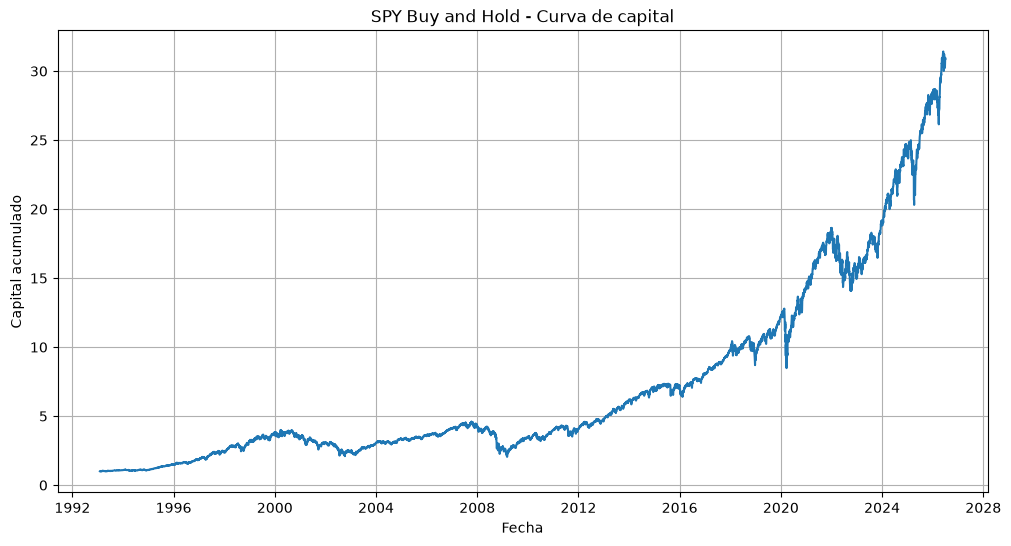

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(equity_curve.index, equity_curve)
plt.title("SPY Buy and Hold - Curva de capital")
plt.xlabel("Fecha")
plt.ylabel("Capital acumulado")
plt.grid(True)
plt.show()

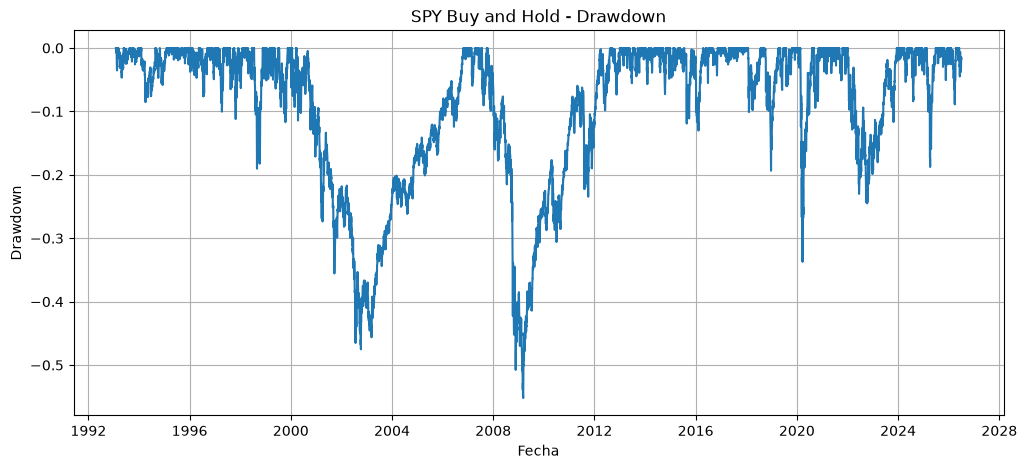

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(drawdown.index, drawdown)
plt.title("SPY Buy and Hold - Drawdown")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

In [18]:
summary = pd.Series({
    "Rentabilidad total": total_return,
    "Rentabilidad anualizada": annualized_return,
    "Volatilidad anualizada": annualized_volatility,
    "Máximo drawdown": max_drawdown
})

summary_percent = summary * 100

summary_percent

Rentabilidad total         2988.673142
Rentabilidad anualizada      10.812041
Volatilidad anualizada       18.573180
Máximo drawdown             -55.189449
dtype: float64

## Conclusiones iniciales

La estrategia buy and hold consiste en comprar SPY al inicio del periodo y mantenerlo hasta el final.

Esta estrategia servirá como benchmark para comparar futuras estrategias.

La curva de capital muestra el crecimiento acumulado de una unidad monetaria invertida inicialmente.

El drawdown muestra las caídas desde máximos históricos anteriores. Es una medida importante porque permite observar cuánto habría llegado a perder temporalmente un inversor durante el periodo analizado.

Aunque la rentabilidad total puede ser elevada en horizontes largos, el máximo drawdown muestra que mantener una inversión pasiva también puede implicar caídas significativas.

Precio ajustado
      ↓
Rendimientos diarios
      ↓
Curva de capital
      ↓
Rentabilidad total
      ↓
Rentabilidad anualizada
      ↓
Volatilidad anualizada
      ↓
Drawdown y máximo drawdown

Rentabilidad total       → cuánto gané en todo el periodo
Rentabilidad anualizada  → a qué tasa anual compuesta crecí
Volatilidad anualizada   → cuánto fluctuó la estrategia en escala anual
Drawdown                 → cuánto caí desde máximos previos
Máximo drawdown          → peor caída sufrida
Curva de capital         → evolución del dinero invertido